In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
RANDOM_SEED = 42
AUTOTUNE    = tf.data.AUTOTUNE
MAX_EPOCHS  = 50
LR_WARMUP   = 0.001
LR_FINETUNE = 0.00005

# ── Load CSVs ──────────────────────────────────────────
train_df = pd.read_csv(f"{RESULTS}/train.csv",
                       encoding='utf-8')
val_df   = pd.read_csv(f"{RESULTS}/val.csv",
                       encoding='utf-8')
test_df  = pd.read_csv(f"{RESULTS}/test.csv",
                       encoding='utf-8')

print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ TensorFlow   : {tf.__version__}")
print(f"✅ Train rows   : {len(train_df):,}")
print(f"✅ Val rows     : {len(val_df):,}")
print(f"✅ Test rows    : {len(test_df):,}")
print(f"✅ IMG_SIZE     : {IMG_SIZE}x{IMG_SIZE}")
print(f"✅ BATCH_SIZE   : {BATCH_SIZE}")
print(f"✅ MAX_EPOCHS   : {MAX_EPOCHS}")
print(f"✅ LR_WARMUP    : {LR_WARMUP}")
print(f"✅ LR_FINETUNE  : {LR_FINETUNE}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: SETUP COMPLETE
✅ TensorFlow   : 2.19.0
✅ Train rows   : 4,087
✅ Val rows     : 877
✅ Test rows    : 876
✅ IMG_SIZE     : 224x224
✅ BATCH_SIZE   : 16
✅ MAX_EPOCHS   : 50
✅ LR_WARMUP    : 0.001
✅ LR_FINETUNE  : 5e-05
✅ Cell 0 complete - Ready to proceed


In [2]:
# Cell 1: Load DenseNet121 pretrained base model

print("=" * 50)
print("   CELL 1: LOADING DENSENET121 BASE")
print("=" * 50)
print("⏳ Loading DenseNet121 with ImageNet weights...")
print()

# Load DenseNet121 base model
# include_top=False removes the final classification layer
# We will add our own custom head instead
base_model = DenseNet121(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

# Count total layers
total_layers = len(base_model.layers)

print(f"✅ DenseNet121 loaded successfully")
print()
print(f"   Model Statistics:")
print(f"   Total layers     : {total_layers}")
print(f"   Input shape      : {base_model.input_shape}")
print(f"   Output shape     : {base_model.output_shape}")
print()

# Show first 5 and last 5 layer names
print(f"   First 5 layers:")
for i in range(5):
    print(f"   [{i:3d}] {base_model.layers[i].name}")

print(f"   ...")
print(f"   Last 5 layers:")
for i in range(total_layers-5, total_layers):
    print(f"   [{i:3d}] {base_model.layers[i].name}")

print()

# Show layer 300 (fine-tuning boundary)
print(f"   Fine-tuning boundary:")
print(f"   Layer 299 : {base_model.layers[299].name}")
print(f"   Layer 300 : {base_model.layers[300].name}")
print(f"   Layers 0-299   → will be FROZEN")
print(f"   Layers 300-{total_layers-1} → will be TRAINABLE")

print("=" * 50)
print("✅ Cell 1 complete")

   CELL 1: LOADING DENSENET121 BASE
⏳ Loading DenseNet121 with ImageNet weights...

✅ DenseNet121 loaded successfully

   Model Statistics:
   Total layers     : 427
   Input shape      : (None, 224, 224, 3)
   Output shape     : (None, 7, 7, 1024)

   First 5 layers:
   [  0] input_layer
   [  1] zero_padding2d
   [  2] conv1_conv
   [  3] conv1_bn
   [  4] conv1_relu
   ...
   Last 5 layers:
   [422] conv5_block16_1_relu
   [423] conv5_block16_2_conv
   [424] conv5_block16_concat
   [425] bn
   [426] relu

   Fine-tuning boundary:
   Layer 299 : conv4_block23_1_relu
   Layer 300 : conv4_block23_2_conv
   Layers 0-299   → will be FROZEN
   Layers 300-426 → will be TRAINABLE
✅ Cell 1 complete


In [3]:
# Cell 2: Freeze base layers 0-299, unfreeze 300+

print("=" * 50)
print("   CELL 2: FREEZING/UNFREEZING LAYERS")
print("=" * 50)
print("   Strategy:")
print("   Layers 0-299   → FROZEN   (keep ImageNet weights)")
print("   Layers 300-426 → TRAINABLE (adapt to X-rays)")
print()

# Freeze ALL base layers first
base_model.trainable = True

# Then freeze only layers 0-299
for i, layer in enumerate(base_model.layers):
    if i < 300:
        layer.trainable = False
    else:
        layer.trainable = True

# Count frozen and trainable layers
frozen    = sum(1 for layer in base_model.layers
                if not layer.trainable)
trainable = sum(1 for layer in base_model.layers
                if layer.trainable)

print(f"✅ Frozen layers    : {frozen}  (layers 0-299)")
print(f"✅ Trainable layers : {trainable} (layers 300+)")
print()

# Count trainable parameters
trainable_params = sum(
    tf.size(w).numpy()
    for w in base_model.trainable_weights
)
frozen_params = sum(
    tf.size(w).numpy()
    for w in base_model.non_trainable_weights
)

print(f"   Parameter counts (base model only):")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Frozen params    : {frozen_params:,}")
print()

# Show boundary layers
print(f"   Last frozen layer    : "
      f"[299] {base_model.layers[299].name}")
print(f"   First trainable layer: "
      f"[300] {base_model.layers[300].name}")

print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: FREEZING/UNFREEZING LAYERS
   Strategy:
   Layers 0-299   → FROZEN   (keep ImageNet weights)
   Layers 300-426 → TRAINABLE (adapt to X-rays)

✅ Frozen layers    : 300  (layers 0-299)
✅ Trainable layers : 127 (layers 300+)

   Parameter counts (base model only):
   Trainable params : 2,889,408
   Frozen params    : 4,148,096

   Last frozen layer    : [299] conv4_block23_1_relu
   First trainable layer: [300] conv4_block23_2_conv
✅ Cell 2 complete


In [4]:
# Cell 3: Add dual pooling and custom classification head

print("=" * 50)
print("   CELL 3: BUILDING CUSTOM MODEL HEAD")
print("=" * 50)
print("   Architecture:")
print("   DenseNet121 base")
print("   → GlobalAveragePooling2D ──┐")
print("   → GlobalMaxPooling2D    ──┤ concatenate")
print("   → BatchNormalization")
print("   → Dense(512, relu) → Dropout(0.5)")
print("   → Dense(256, relu) → Dropout(0.4)")
print("   → Dense(128, relu) → Dropout(0.3)")
print("   → Dense(1, sigmoid)")
print()

# ── Get base model output ──────────────────────────────
x = base_model.output

# ── Dual Pooling ───────────────────────────────────────
# Average pooling captures overall feature intensity
avg = GlobalAveragePooling2D()(x)

# Max pooling captures strongest activated features
mx  = GlobalMaxPooling2D()(x)

# Concatenate both - richer feature representation
# Use lowercase concatenate (function not class)
x   = concatenate([avg, mx])

# ── Custom Classification Head ─────────────────────────
# BatchNorm stabilizes training
x = BatchNormalization()(x)

# Dense layer 1
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# Dense layer 2
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

# Dense layer 3
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer - sigmoid for binary classification
# Output: 0.0-1.0 probability
# >= 0.5 = Pneumonia, < 0.5 = Normal
output = Dense(1, activation='sigmoid')(x)

# ── Build final model ──────────────────────────────────
model = Model(
    inputs  = base_model.input,
    outputs = output,
    name    = 'DenseNet121_XRay'
)

print(f"✅ Dual pooling added")
print(f"   GlobalAveragePooling2D : output shape (None, 1024)")
print(f"   GlobalMaxPooling2D     : output shape (None, 1024)")
print(f"   After concatenate      : output shape (None, 2048)")
print()
print(f"✅ Custom head added")
print(f"   BatchNormalization")
print(f"   Dense(512) → Dropout(0.5)")
print(f"   Dense(256) → Dropout(0.4)")
print(f"   Dense(128) → Dropout(0.3)")
print(f"   Dense(1, sigmoid) ← output layer")
print()
print(f"✅ Model built successfully")
print(f"   Model name : {model.name}")
print(f"   Input shape: {model.input_shape}")
print(f"   Output shape:{model.output_shape}")
print("=" * 50)
print("✅ Cell 3 complete")

   CELL 3: BUILDING CUSTOM MODEL HEAD
   Architecture:
   DenseNet121 base
   → GlobalAveragePooling2D ──┐
   → GlobalMaxPooling2D    ──┤ concatenate
   → BatchNormalization
   → Dense(512, relu) → Dropout(0.5)
   → Dense(256, relu) → Dropout(0.4)
   → Dense(128, relu) → Dropout(0.3)
   → Dense(1, sigmoid)

✅ Dual pooling added
   GlobalAveragePooling2D : output shape (None, 1024)
   GlobalMaxPooling2D     : output shape (None, 1024)
   After concatenate      : output shape (None, 2048)

✅ Custom head added
   BatchNormalization
   Dense(512) → Dropout(0.5)
   Dense(256) → Dropout(0.4)
   Dense(128) → Dropout(0.3)
   Dense(1, sigmoid) ← output layer

✅ Model built successfully
   Model name : DenseNet121_XRay
   Input shape: (None, 224, 224, 3)
   Output shape:(None, 1)
✅ Cell 3 complete


In [5]:
# Cell 4: Compile model with optimizer and metrics

print("=" * 50)
print("   CELL 4: COMPILING MODEL")
print("=" * 50)

# Compile model
# Adam optimizer with initial learning rate
# binary_crossentropy for binary classification
# Track 4 metrics during training
model.compile(
    optimizer = Adam(learning_rate=LR_WARMUP),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f"✅ Optimizer  : Adam")
print(f"   LR Warmup  : {LR_WARMUP}")
print(f"   LR Finetune: {LR_FINETUNE} (used in Notebook 5)")
print()
print(f"✅ Loss       : binary_crossentropy")
print(f"   Reason     : Binary classification")
print(f"                (Normal vs Pneumonia)")
print()
print(f"✅ Metrics tracked:")
print(f"   • accuracy  : overall correct predictions")
print(f"   • auc       : area under ROC curve")
print(f"   • precision : TP / (TP + FP)")
print(f"   • recall    : TP / (TP + FN) ← most important")
print()
print(f"✅ Model compiled successfully")
print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: COMPILING MODEL
✅ Optimizer  : Adam
   LR Warmup  : 0.001
   LR Finetune: 5e-05 (used in Notebook 5)

✅ Loss       : binary_crossentropy
   Reason     : Binary classification
                (Normal vs Pneumonia)

✅ Metrics tracked:
   • accuracy  : overall correct predictions
   • auc       : area under ROC curve
   • precision : TP / (TP + FP)
   • recall    : TP / (TP + FN) ← most important

✅ Model compiled successfully
✅ Cell 4 complete


In [6]:
# Cell 5: Print complete model summary

print("=" * 50)
print("   CELL 5: MODEL SUMMARY")
print("=" * 50)

# Print full model summary
model.summary()

print()

# Count parameters manually for clarity
total_params     = model.count_params()
trainable_params = sum(
    tf.size(w).numpy()
    for w in model.trainable_weights
)
frozen_params = total_params - trainable_params

print("=" * 50)
print(f"   Parameter Summary:")
print(f"   Total params     : {total_params:>12,}")
print(f"   Trainable params : {trainable_params:>12,}")
print(f"   Frozen params    : {frozen_params:>12,}")
print()

# Verify architecture is correct
print(f"   Architecture Verification:")
print(f"   Input  shape : {model.input_shape}")
print(f"   Output shape : {model.output_shape}")

# Check output activation
last_layer = model.layers[-1]
print(f"   Last layer   : {last_layer.name}")
print(f"   Activation   : sigmoid ✅")
print()

# Memory estimate
params_mb = total_params * 4 / (1024 * 1024)
print(f"   Estimated model size : ~{params_mb:.1f} MB")
print("=" * 50)
print("✅ Cell 5 complete")

   CELL 5: MODEL SUMMARY


Model: "DenseNet121_XRay"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 8,259,137 (31.51 MB)

 Trainable params: 4,106,945 (15.67 MB)

 Non-trainable params: 4,152,192 (15.84 MB)


   Parameter Summary:
   Total params     :    8,259,137
   Trainable params :    4,106,945
   Frozen params    :    4,152,192

   Architecture Verification:
   Input  shape : (None, 224, 224, 3)
   Output shape : (None, 1)
   Last layer   : dense_3
   Activation   : sigmoid ✅

   Estimated model size : ~31.5 MB
✅ Cell 5 complete


In [7]:
# Cell 6: Compute class weights for imbalanced dataset

print("=" * 50)
print("   CELL 6: COMPUTING CLASS WEIGHTS")
print("=" * 50)
print("   Reason: Dataset is imbalanced")
print("   NORMAL    : 1,575 (27%)")
print("   PNEUMONIA : 4,265 (73%)")
print("   Without weights model ignores minority class")
print()

# Get labels from training set
train_labels = train_df['label'].values

# Compute balanced class weights
# 'balanced' mode: weight = n_samples/(n_classes*n_samples_class)
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1]),
    y            = train_labels
)

# Convert to dictionary format needed by Keras
class_weight_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

# Count per class in training set
n_normal  = (train_labels == 0).sum()
n_pneumo  = (train_labels == 1).sum()
n_total   = len(train_labels)

print(f"   Training set breakdown:")
print(f"   Class 0 (Normal)    : {n_normal:,} samples")
print(f"   Class 1 (Pneumonia) : {n_pneumo:,} samples")
print(f"   Total               : {n_total:,} samples")
print()
print(f"✅ Class weights computed:")
print(f"   Class 0 (Normal)    : "
      f"{class_weight_dict[0]:.4f} ← weighted HIGHER")
print(f"   Class 1 (Pneumonia) : "
      f"{class_weight_dict[1]:.4f} ← weighted LOWER")
print()
print(f"   Interpretation:")
print(f"   Each Normal error counts "
      f"{class_weight_dict[0]:.2f}x more than Pneumonia error")
print(f"   This forces model to pay attention to")
print(f"   the minority class (Normal)")
print()

# Save class weights for use in Notebook 5
import pickle
cw_path = f"{RESULTS}/class_weights.pkl"
with open(cw_path, 'wb') as f:
    pickle.dump(class_weight_dict, f)

print(f"✅ Class weights saved : {cw_path}")
print("=" * 50)
print("✅ Cell 6 complete")

   CELL 6: COMPUTING CLASS WEIGHTS
   Reason: Dataset is imbalanced
   NORMAL    : 1,575 (27%)
   PNEUMONIA : 4,265 (73%)
   Without weights model ignores minority class

   Training set breakdown:
   Class 0 (Normal)    : 1,102 samples
   Class 1 (Pneumonia) : 2,985 samples
   Total               : 4,087 samples

✅ Class weights computed:
   Class 0 (Normal)    : 1.8544 ← weighted HIGHER
   Class 1 (Pneumonia) : 0.6846 ← weighted LOWER

   Interpretation:
   Each Normal error counts 1.85x more than Pneumonia error
   This forces model to pay attention to
   the minority class (Normal)

✅ Class weights saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/class_weights.pkl
✅ Cell 6 complete


In [8]:
# Cell 7: Setup all training callbacks

print("=" * 50)
print("   CELL 7: SETTING UP CALLBACKS")
print("=" * 50)

# ── Model save path ────────────────────────────────────
model_save_path = f"{MODELS}/densenet_best.keras"

# ── Callback 1: ModelCheckpoint ───────────────────────
# Saves best model automatically based on val_auc
checkpoint = ModelCheckpoint(
    filepath          = model_save_path,
    monitor           = 'val_auc',
    mode              = 'max',
    save_best_only    = True,
    save_weights_only = False,
    verbose           = 1
)

# ── Callback 2: EarlyStopping ─────────────────────────
# Stops training when val_auc stops improving
# patience=15 means wait 15 epochs before stopping
early_stop = EarlyStopping(
    monitor              = 'val_auc',
    mode                 = 'max',
    patience             = 15,
    restore_best_weights = True,
    verbose              = 1
)

# ── Callback 3: ReduceLROnPlateau ─────────────────────
# Reduces LR when training plateaus
# factor=0.3 means new_lr = old_lr * 0.3
reduce_lr = ReduceLROnPlateau(
    monitor   = 'val_auc',
    mode      = 'max',
    factor    = 0.3,
    patience  = 5,
    min_lr    = 1e-8,
    verbose   = 1
)

# ── Store all callbacks in list ────────────────────────
callbacks = [checkpoint, early_stop, reduce_lr]

# ── Save callbacks config for Notebook 5 ──────────────
import pickle
callbacks_config = {
    'model_save_path' : model_save_path,
    'monitor'         : 'val_auc',
    'es_patience'     : 15,
    'rlr_factor'      : 0.3,
    'rlr_patience'    : 5,
    'min_lr'          : 1e-8
}
config_path = f"{RESULTS}/callbacks_config.pkl"
with open(config_path, 'wb') as f:
    pickle.dump(callbacks_config, f)

print(f"✅ Callback 1: ModelCheckpoint")
print(f"   Monitor    : val_auc (save best only)")
print(f"   Save path  : {model_save_path}")
print()
print(f"✅ Callback 2: EarlyStopping")
print(f"   Monitor    : val_auc")
print(f"   Patience   : 15 epochs")
print(f"   Restore    : best weights on stop")
print()
print(f"✅ Callback 3: ReduceLROnPlateau")
print(f"   Monitor    : val_auc")
print(f"   Factor     : 0.3 (LR × 0.3 on plateau)")
print(f"   Patience   : 5 epochs")
print(f"   Min LR     : 1e-8")
print()
print(f"✅ All 3 callbacks ready")
print(f"✅ Config saved : {config_path}")
print("=" * 50)
print("✅ Cell 7 complete")

   CELL 7: SETTING UP CALLBACKS
✅ Callback 1: ModelCheckpoint
   Monitor    : val_auc (save best only)
   Save path  : D:/Projects/Harsh_Mini_Project/medical_xray_project/models/densenet_best.keras

✅ Callback 2: EarlyStopping
   Monitor    : val_auc
   Patience   : 15 epochs
   Restore    : best weights on stop

✅ Callback 3: ReduceLROnPlateau
   Monitor    : val_auc
   Factor     : 0.3 (LR × 0.3 on plateau)
   Patience   : 5 epochs
   Min LR     : 1e-8

✅ All 3 callbacks ready
✅ Config saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/callbacks_config.pkl
✅ Cell 7 complete


   CELL 8: ARCHITECTURE DIAGRAM


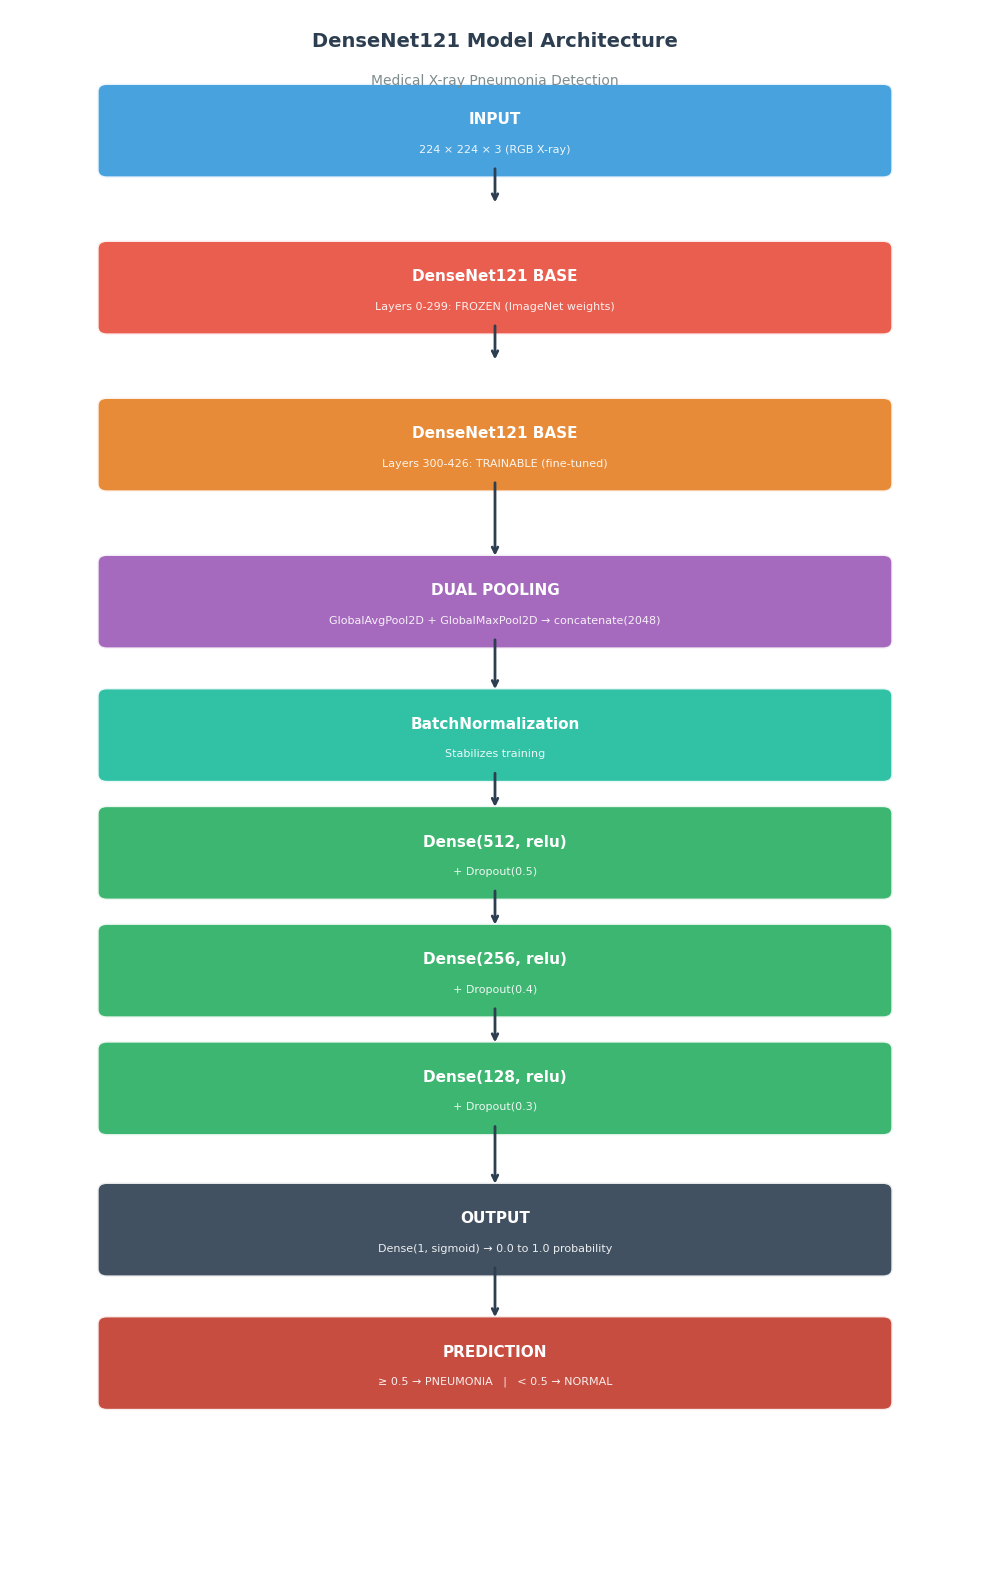

✅ Architecture diagram saved
   Path : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/model_architecture.png

   Layers shown:
   • Input      : 224×224×3
   • DenseNet   : Frozen + Trainable sections
   • DualPool   : AvgPool + MaxPool → concat
   • Head       : BN → 512 → 256 → 128 → 1
   • Output     : Sigmoid probability
✅ Cell 8 complete


In [9]:
# Cell 8: Draw model architecture diagram

print("=" * 50)
print("   CELL 8: ARCHITECTURE DIAGRAM")
print("=" * 50)

fig, ax = plt.subplots(1, 1, figsize=(10, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# ── Define layers to draw ──────────────────────────────
layers = [
    # (y_pos, label, sublabel, color)
    (18.5, "INPUT",
     "224 × 224 × 3 (RGB X-ray)", "#3498db"),
    (16.5, "DenseNet121 BASE",
     "Layers 0-299: FROZEN (ImageNet weights)", "#e74c3c"),
    (14.5, "DenseNet121 BASE",
     "Layers 300-426: TRAINABLE (fine-tuned)", "#e67e22"),
    (12.5, "DUAL POOLING",
     "GlobalAvgPool2D + GlobalMaxPool2D → concatenate(2048)",
     "#9b59b6"),
    (10.8, "BatchNormalization",
     "Stabilizes training", "#1abc9c"),
    (9.3,  "Dense(512, relu)",
     "+ Dropout(0.5)", "#27ae60"),
    (7.8,  "Dense(256, relu)",
     "+ Dropout(0.4)", "#27ae60"),
    (6.3,  "Dense(128, relu)",
     "+ Dropout(0.3)", "#27ae60"),
    (4.5,  "OUTPUT",
     "Dense(1, sigmoid) → 0.0 to 1.0 probability",
     "#2c3e50"),
    (2.8,  "PREDICTION",
     "≥ 0.5 → PNEUMONIA   |   < 0.5 → NORMAL",
     "#c0392b"),
]

# ── Draw each layer box ────────────────────────────────
for y, title, subtitle, color in layers:
    # Draw box
    rect = mpatches.FancyBboxPatch(
        (1, y - 0.55), 8, 1.0,
        boxstyle = "round,pad=0.1",
        facecolor = color,
        edgecolor = 'white',
        linewidth = 2,
        alpha     = 0.9
    )
    ax.add_patch(rect)

    # Title text
    ax.text(5, y + 0.1, title,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white')

    # Subtitle text
    ax.text(5, y - 0.28, subtitle,
            ha='center', va='center',
            fontsize=8, color='white', alpha=0.9)

# ── Draw arrows between layers ─────────────────────────
arrow_positions = [
    (18.0, 17.5), (16.0, 15.5),
    (14.0, 13.0), (12.0, 11.3),
    (10.3, 9.8),  (8.8,  8.3),
    (7.3,  6.8),  (5.8,  5.0),
    (4.0,  3.3),
]
for y_start, y_end in arrow_positions:
    ax.annotate(
        '', xy=(5, y_end),
        xytext=(5, y_start),
        arrowprops=dict(
            arrowstyle='->', color='#2c3e50',
            lw=2.0
        )
    )

# ── Title ──────────────────────────────────────────────
ax.text(5, 19.6,
        'DenseNet121 Model Architecture',
        ha='center', va='center',
        fontsize=14, fontweight='bold',
        color='#2c3e50')

ax.text(5, 19.1,
        'Medical X-ray Pneumonia Detection',
        ha='center', va='center',
        fontsize=10, color='#7f8c8d')

plt.tight_layout()

# Save diagram
save_path = f"{PLOTS}/model_architecture.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()

print(f"✅ Architecture diagram saved")
print(f"   Path : {save_path}")
print()
print(f"   Layers shown:")
print(f"   • Input      : 224×224×3")
print(f"   • DenseNet   : Frozen + Trainable sections")
print(f"   • DualPool   : AvgPool + MaxPool → concat")
print(f"   • Head       : BN → 512 → 256 → 128 → 1")
print(f"   • Output     : Sigmoid probability")
print("=" * 50)
print("✅ Cell 8 complete")